In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load Data Bersih
df = pd.read_csv('../01-Data-Preprocessing/jdm_used_cars_cleaned.csv')

# 2. Menentukan Batas Harga (Kita pakai Median agar adil 50:50)
batas_harga = df['price'].median()

# 3. Membuat kolom target baru: 1 jika Premium (> median), 0 jika Standar
df['is_premium'] = (df['price'] > batas_harga).astype(int)

# 4. MENCEGAH DATA LEAKAGE: Membuang kolom harga asli!
X = df.drop(columns=['price', 'is_premium'])
y = df['is_premium'] # Kunci Jawaban

# 5. Membagi data Ujian dan Latihan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Batas Harga Premium: Rp {batas_harga}")
print("Total Mobil Premium (1) vs Standar (0):")
print(y.value_counts())

Batas Harga Premium: Rp 1008.0
Total Mobil Premium (1) vs Standar (0):
is_premium
0    1143
1    1127
Name: count, dtype: int64


In [2]:
from sklearn.linear_model import LogisticRegression

# 1. Inisialisasi Model (max_iter ditambah agar model tidak kehabisan napas saat belajar)
model_clf = LogisticRegression(max_iter=1000, random_state=42)

# 2. Proses Belajar
model_clf.fit(X_train, y_train)

# 3. Minta model menebak soal ujian
y_pred = model_clf.predict(X_test)

print("✅ Model Klasifikasi berhasil dilatih!")

✅ Model Klasifikasi berhasil dilatih!


🏆 Akurasi Model: 63.00%



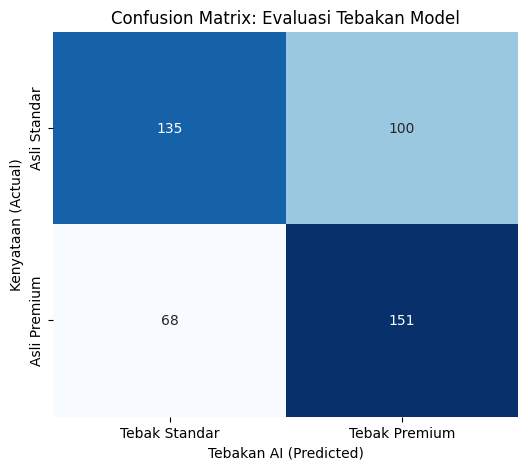

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"🏆 Akurasi Model: {akurasi * 100:.2f}%\n")

# 2. Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tebak Standar', 'Tebak Premium'],
            yticklabels=['Asli Standar', 'Asli Premium'])

plt.title('Confusion Matrix: Evaluasi Tebakan Model')
plt.xlabel('Tebakan AI (Predicted)')
plt.ylabel('Kenyataan (Actual)')
plt.show()

In [4]:
from sklearn.metrics import classification_report

# Menampilkan laporan metrik klasifikasi secara lengkap
laporan = classification_report(y_test, y_pred, target_names=['Standar (0)', 'Premium (1)'])

print("📑 --- CLASSIFICATION REPORT (LOGISTIC REGRESSION) --- 📑\n")
print(laporan)

📑 --- CLASSIFICATION REPORT (LOGISTIC REGRESSION) --- 📑

              precision    recall  f1-score   support

 Standar (0)       0.67      0.57      0.62       235
 Premium (1)       0.60      0.69      0.64       219

    accuracy                           0.63       454
   macro avg       0.63      0.63      0.63       454
weighted avg       0.63      0.63      0.63       454



In [5]:
from sklearn.ensemble import RandomForestClassifier

# 1. Inisialisasi Model Random Forest untuk KLASIFIKASI (Bukan Regresi)
model_rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Proses Belajar
model_rf_clf.fit(X_train, y_train)

# 3. Tebak soal ujian
y_pred_rf = model_rf_clf.predict(X_test)

# 4. Tampilkan Rapor Baru
print("🌳 --- CLASSIFICATION REPORT (RANDOM FOREST) --- 🌳\n")
print(classification_report(y_test, y_pred_rf, target_names=['Standar (0)', 'Premium (1)']))

🌳 --- CLASSIFICATION REPORT (RANDOM FOREST) --- 🌳

              precision    recall  f1-score   support

 Standar (0)       0.66      0.63      0.65       235
 Premium (1)       0.62      0.64      0.63       219

    accuracy                           0.64       454
   macro avg       0.64      0.64      0.64       454
weighted avg       0.64      0.64      0.64       454



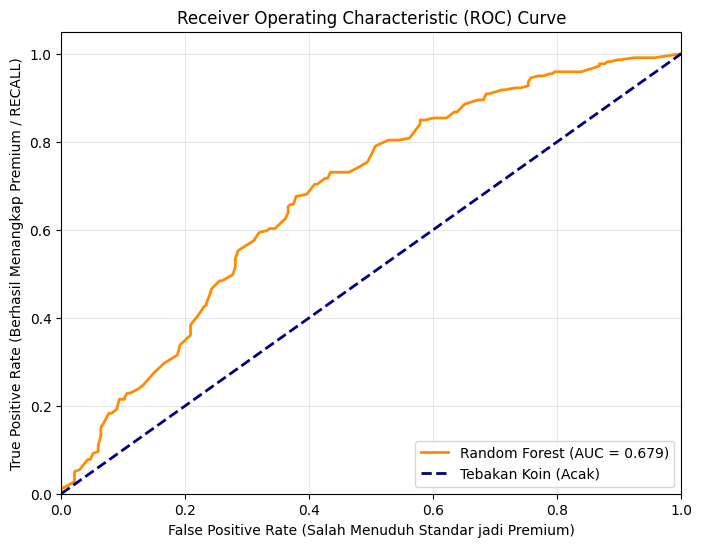

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Meminta model mengeluarkan "Peluang Persentase" (Probability), bukan cuma tebakan 1/0
# [:, 1] artinya kita hanya mengambil kolom probabilitas untuk kelas 1 (Premium)
y_prob_rf = model_rf_clf.predict_proba(X_test)[:, 1]

# 2. Menghitung koordinat untuk Kurva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# 3. Menghitung skor AUC (Area Under Curve) - Rapor Final Keseluruhan
roc_auc = auc(fpr, tpr)

# 4. Visualisasi Kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Tebakan Koin (Acak)')

# Mempercantik grafik
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Salah Menuduh Standar jadi Premium)')
plt.ylabel('True Positive Rate (Berhasil Menangkap Premium / RECALL)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()